# Project Analyse de donnée Netflix
# Groupe 5
# Mohamed Ouledelabd
# Taha Nasiri
# Badr Icame

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement de la base de donnée:
net = pd.read_csv('netflix.csv')

# Pour voir les colonnes de la base de donnee

In [25]:
net.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

# Question1: Top 5 des meilleures catégories.

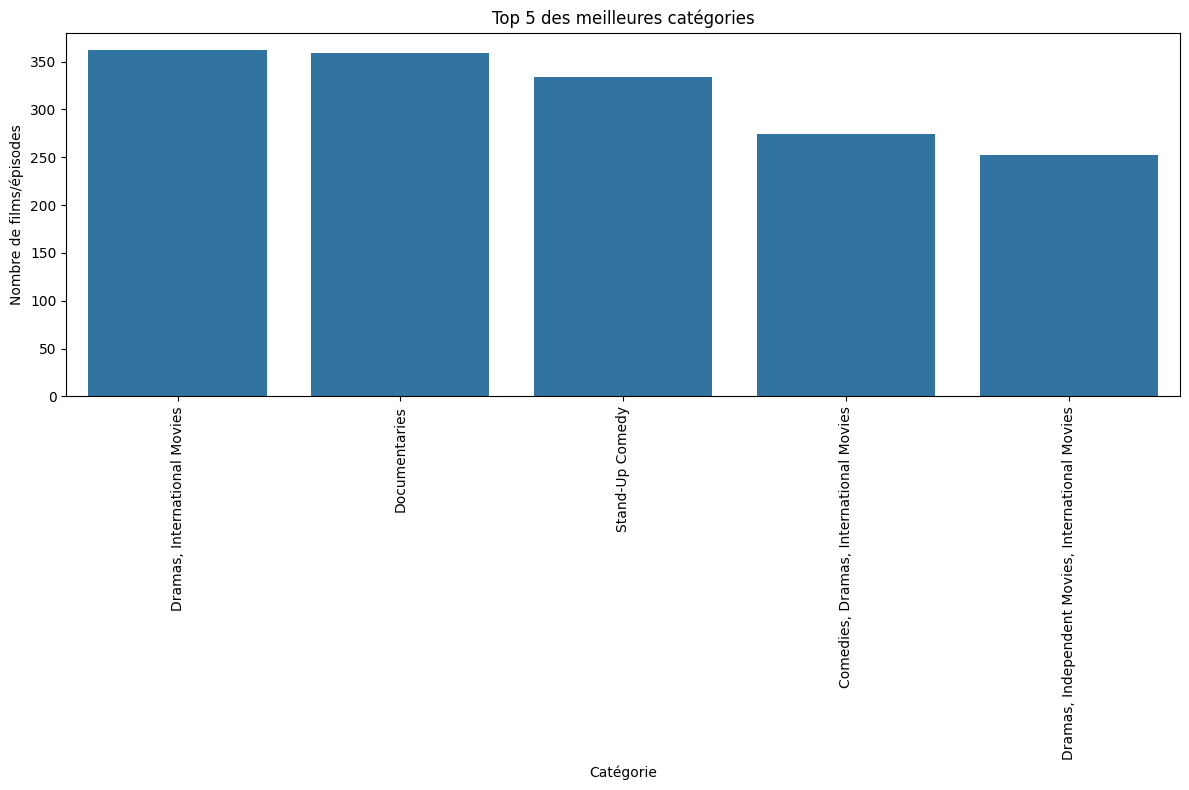

In [125]:
# Calcul du nombre de films/épisodes par catégorie
category_counts = net['listed_in'].value_counts()

# Affichage des 5 meilleures catégories
plt.figure(figsize=(12, 8))
sns.barplot(x=category_counts.index[:5], y=category_counts.values[:5])
plt.title('Top 5 des meilleures catégories')
plt.xlabel('Catégorie')
plt.ylabel('Nombre de films/épisodes')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Question2: Top 5 des réalisateurs

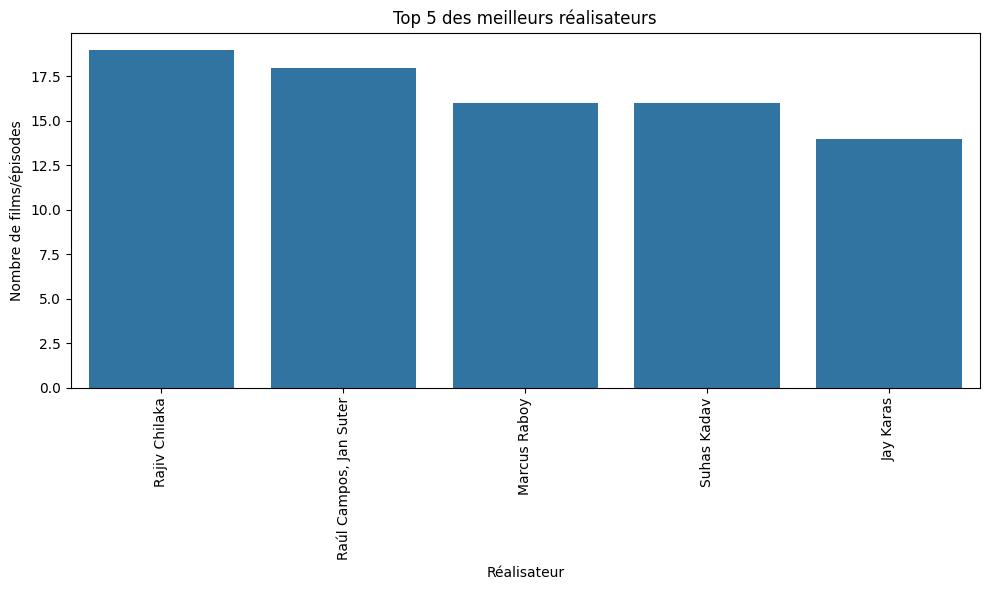

In [126]:
# Calcul du nombre de films/épisodes par réalisateur
director_counts = net['director'].value_counts()

# Affichage des 5 meilleurs réalisateurs
plt.figure(figsize=(10, 6))
sns.barplot(x=director_counts.index[:5], y=director_counts.values[:5])
plt.title('Top 5 des meilleurs réalisateurs')
plt.xlabel('Réalisateur')
plt.ylabel('Nombre de films/épisodes')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Question3: Les dix meilleurs acteurs

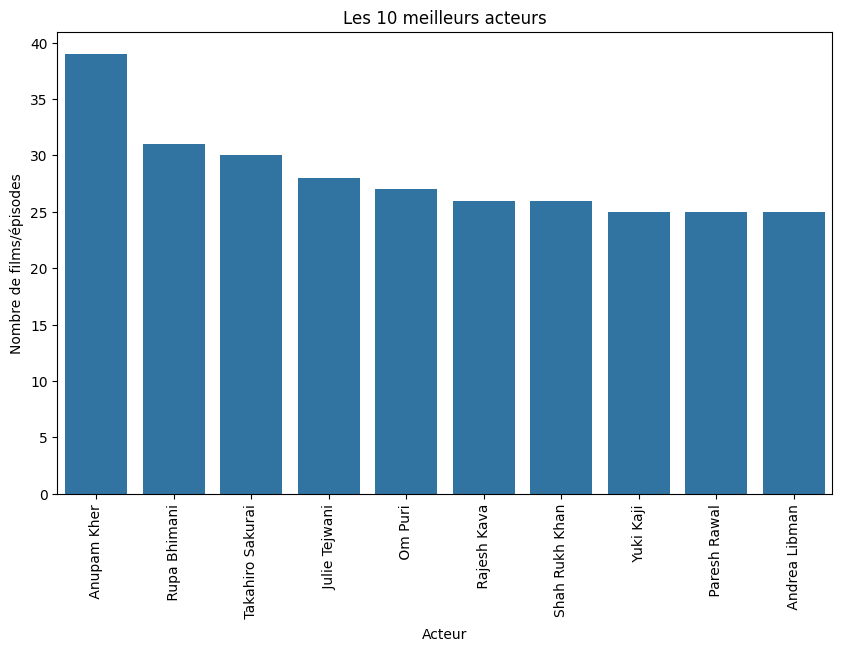

In [127]:
# Calcul du nombre de films/épisodes par acteur
actor_counts = net['cast'].str.split(',').explode().value_counts()

# Affichage des 10 meilleurs acteurs
plt.figure(figsize=(10, 6))
sns.barplot(x=actor_counts.index[:10], y=actor_counts.values[:10])
plt.title('Les 10 meilleurs acteurs')
plt.xlabel('Acteur')
plt.ylabel('Nombre de films/épisodes')
plt.xticks(rotation=90)
plt.show()

# Question4: Les cinq meilleures séries télévisées avec le plus grand nombre de saisons

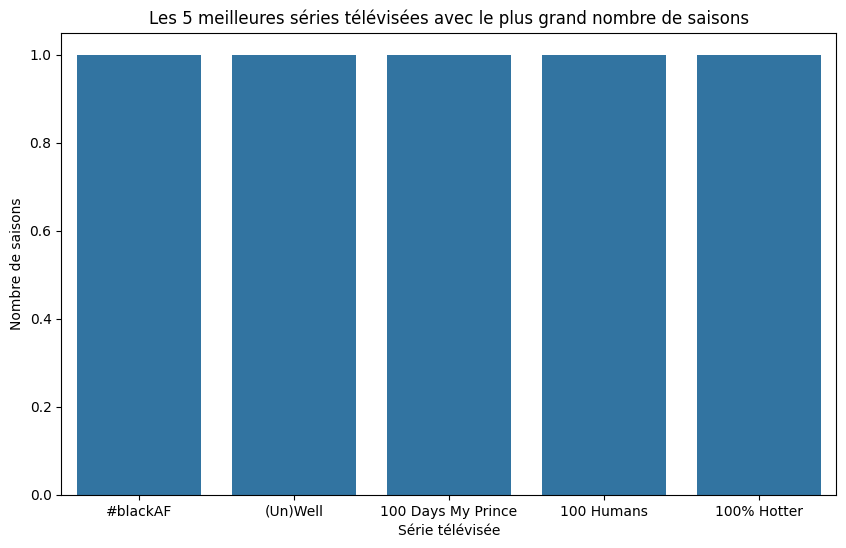

In [128]:
# Calcul du nombre de saisons par série télévisée
show_seasons = net[net['type'] == 'TV Show'].groupby('title')['duration'].count()

# Affichage des 5 meilleures séries télévisées
plt.figure(figsize=(10, 6))
sns.barplot(x=show_seasons.index[:5], y=show_seasons.values[:5])
plt.title('Les 5 meilleures séries télévisées avec le plus grand nombre de saisons')
plt.xlabel('Série télévisée')
plt.ylabel('Nombre de saisons')
plt.show()

# Question5: Identifier des contenus similaires en faisant correspondre des caractéristiques textuelles

In [129]:
# Calcul de la similarité entre les titres de contenu
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

#Create object, which will transform the titles into a matrix of TF-IDF features.
vectorizer = TfidfVectorizer()

#transforme les titres de la colonne 'title' du DataFrame net en vecteurs TF-IDF en utilisant l'objet vectorizer
title_vectors = vectorizer.fit_transform(net['title'])

#calcule la similarité cosine entre tous les vecteurs TF-IDF dans title_vectors
similarity_matrix = cosine_similarity(title_vectors)

# Affichage des 5 contenus les plus similaires pour le premier titre
similar_titles = similarity_matrix[1].argsort()[:-6:-1]
print('Les 5 contenus les plus similaires au titre "{}" sont :'.format(net['title'].iloc[0]))
print(net['title'].iloc[similar_titles])

Les 5 contenus les plus similaires au titre "Dick Johnson Is Dead" sont :
1       Blood & Water
231     The Water Man
4872     Family Blood
6587       Deep Water
3787        Bad Blood
Name: title, dtype: object


# Question6: Netflix se concentre-t-il davantage sur les séries télévisées que sur les films ces dernières années?

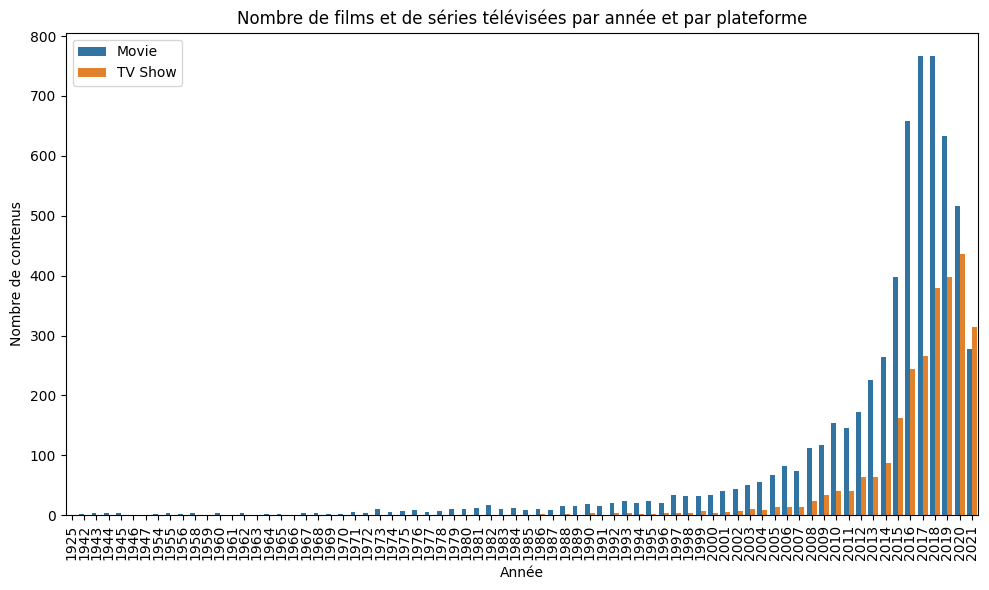

In [130]:
# groupe les données par année de sortie et type de contenu (film ou série télévisée) et compte le nombre de contenus pour chaque groupe
platform_year_counts = net.groupby(['release_year', 'type'])['type'].count().unstack()

# réinitialise l'index du tableau pour pouvoir l'utiliser comme colonne.
platform_year_counts = platform_year_counts.reset_index()

# renomme la colonne "type" en "count"
platform_year_counts = platform_year_counts.rename(columns={'type': 'count'})

# transforme le tableau pour avoir les années de sortie en index et les types de contenu en colonnes.
platform_year_counts = platform_year_counts.melt(id_vars='release_year', var_name='type', value_name='count')

plt.figure(figsize=(10, 6))
# Le paramètre "hue" est utilisé pour distinguer les deux types de contenu.
sns.barplot(x='release_year', y='count', hue='type', data=platform_year_counts) 
plt.title('Nombre de films et de séries télévisées par année et par plateforme')
plt.xlabel('Année')
plt.ylabel('Nombre de contenus')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()